# 07 — XGBoost (modelo competidor)

**Objetivo:** Entrenar un segundo modelo de gradient boosting (XGBoost) para comparar contra LightGBM y demostrar la robustez del enfoque metodológico.

**Fase CRISP-DM:** 4 — Modelado.

**Inputs:**
- `data/processed/dataset_modelable.parquet` — dataset con 29 features
- Tabla `pronosticos` (MySQL) — predicciones de baseline Y LightGBM

**Outputs:**
- Modelo entrenado guardado en `data/processed/xgboost_model.json`
- Predicciones en tabla `pronosticos` (modelo='xgboost')
- Métricas en tabla `metricas_modelos` (modelo='xgboost')
- Comparación de **TRES modelos** lado a lado.

**Por qué comparar XGBoost con LightGBM:**

Ambos son algoritmos de gradient boosting pero con implementaciones distintas:
- **LightGBM** crece árboles leaf-wise (más flexible, más rápido).
- **XGBoost** crece árboles level-wise (más conservador, históricamente más popular).

Si ambos producen resultados similares con el mismo dataset y features, **eso valida que el enfoque metodológico es robusto** y que los hallazgos no dependen del algoritmo específico.

**Hipótesis a validar:**

> XGBoost debería obtener resultados **similares** a LightGBM (diferencia <5% en MAE). Si la diferencia es mayor, indicaría sensibilidad del problema al algoritmo y habría que investigar.

**Autor:** Equipo del proyecto — Diego Andrés De Jesús Montenegro y Luis David Andrade Díaz
**Fecha:** mayo 2026

In [1]:
# =========================
# Imports
# =========================
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import text

import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

from src.db import get_engine

# Configuracion visual
COLOR_PRIMARIO = "#1F4E78"
COLOR_SECUNDARIO = "#E67E22"
COLOR_VERDE = "#27AE60"
COLOR_ROJO = "#C0392B"
COLOR_LIGHTGBM = "#9B59B6"   # Morado
COLOR_XGBOOST = "#16A085"    # Verde azulado distintivo

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FIG_DIR = ROOT / "reports" / "figures" / "xgboost"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    out = FIG_DIR / f"{nombre}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  Guardado: {out.relative_to(ROOT)}")

print("Setup completado.")

XGBoost version: 2.1.3
Setup completado.


## 1. Carga del dataset modelable

In [2]:
ruta_parquet = ROOT / "data" / "processed" / "dataset_modelable.parquet"
dataset = pd.read_parquet(ruta_parquet)
print(f"Dataset: {len(dataset):,} filas x {len(dataset.columns)} columnas")
print(dataset["split"].value_counts())

Dataset: 517,846 filas x 40 columnas
split
train        386661
test_2026     66572
valid         64613
Name: count, dtype: int64


## 2. Carga de predicciones de baseline Y LightGBM (para comparar TRES modelos)

In [3]:
engine = get_engine()

# Cargar predicciones de baseline y LightGBM
preds_otros = pd.read_sql(
    """
    SELECT item, centro_operacion, fecha_inicio_semana,
           cantidad_real, cantidad_predicha, modelo, split
    FROM pronosticos
    WHERE modelo IN ('baseline_ma4', 'lightgbm')
    """,
    engine,
    parse_dates=["fecha_inicio_semana"],
)

# Pivot para tener baseline y lightgbm en columnas
preds_pivot = preds_otros.pivot_table(
    index=["item", "centro_operacion", "fecha_inicio_semana", "split"],
    columns="modelo",
    values="cantidad_predicha",
    aggfunc="first",
).reset_index()
preds_pivot.columns.name = None
preds_pivot = preds_pivot.rename(columns={
    "baseline_ma4": "pred_baseline",
    "lightgbm": "pred_lightgbm",
})

print(f"Predicciones cargadas: {len(preds_pivot):,} filas")
print(f"Modelos disponibles para comparacion: baseline_ma4, lightgbm")

# Cargar clasificacion
clasif = pd.read_sql(
    "SELECT item, clase_abc, segmento_abc_xyz FROM clasificacion_abc_xyz",
    engine,
)
print(f"Clasificacion ABC/XYZ: {len(clasif):,} SKUs")

Predicciones cargadas: 131,185 filas
Modelos disponibles para comparacion: baseline_ma4, lightgbm
Clasificacion ABC/XYZ: 2,380 SKUs


## 3. Separación de features y target

Usamos exactamente las mismas 29 features que LightGBM para comparar de manera justa los dos algoritmos.

In [4]:
# Mismas features que LightGBM
features = [
    "lag_1", "lag_2", "lag_4", "lag_8", "lag_13", "lag_52",
    "rolling_mean_4", "rolling_mean_13", "rolling_std_4", "diff_1",
    "mes", "trimestre", "dia_anio", "sin_mes", "cos_mes",
    "sin_semana", "cos_semana", "num_festivos",
    "nombre_linea_n1_cod", "nombre_linea_n2_cod",
    "proveedor_codigo_cod", "centro_operacion_cod",
    "clase_abc_num", "clase_xyz_num",
    "sku_mean", "sku_median", "sku_std", "sku_min", "sku_max",
]
target = "cantidad_total"

# Separar splits
train = dataset[dataset["split"] == "train"].copy()
valid = dataset[dataset["split"] == "valid"].copy()
test = dataset[dataset["split"] == "test_2026"].copy()

X_train, y_train = train[features], train[target]
X_valid, y_valid = valid[features], valid[target]
X_test, y_test = test[features], test[target]

print(f"Train:      {len(X_train):>8,} filas")
print(f"Validation: {len(X_valid):>8,} filas")
print(f"Test 2026:  {len(X_test):>8,} filas")
print(f"Features: {len(features)}")

Train:       386,661 filas
Validation:   64,613 filas
Test 2026:    66,572 filas
Features: 29


## 4. Hiperparámetros XGBoost (equivalentes a LightGBM)

**Decisión metodológica clave:** usamos hiperparámetros equivalentes a los de LightGBM para que la comparación sea justa. Lo que estamos comparando es el algoritmo, no el tuning.

| LightGBM | XGBoost | Significado |
|---|---|---|
| `learning_rate=0.05` | `learning_rate=0.05` | Tasa de aprendizaje |
| `num_leaves=63` | `max_depth=6` | Complejidad del árbol (2^6=64 ≈ 63 hojas) |
| `min_data_in_leaf=20` | `min_child_weight=20` | Mínimo de muestras por hoja |
| `feature_fraction=0.9` | `colsample_bytree=0.9` | % de features por árbol |
| `bagging_fraction=0.8` | `subsample=0.8` | % de filas por árbol |
| `lambda_l2=0.1` | `reg_lambda=0.1` | Regularización L2 |

In [5]:
xgb_params = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.9,
    "reg_lambda": 0.1,
    "seed": 42,
    "tree_method": "hist",   # Equivalente al modo histograma de LightGBM, mucho mas rapido
    "verbosity": 0,
}

num_boost_round = 1000
early_stopping_rounds = 50

print("Hiperparametros configurados.")

Hiperparametros configurados.


## 5. Entrenamiento de XGBoost

Convertimos a `DMatrix` (formato nativo de XGBoost) y entrenamos con early stopping.

In [6]:
# Crear DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)
dtest = xgb.DMatrix(X_test, label=y_test)

print("Iniciando entrenamiento de XGBoost...")
print("(Imprime cada 50 iteraciones el MAE en train y validation)\n")

evals_result = {}

modelo = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=50,
    evals_result=evals_result,
)

print(f"\nMejor iteracion: {modelo.best_iteration}")
print(f"Mejor MAE en validation: {modelo.best_score:.4f}")

Iniciando entrenamiento de XGBoost...
(Imprime cada 50 iteraciones el MAE en train y validation)

[0]	train-mae:76.08105	valid-mae:80.14524
[50]	train-mae:14.17260	valid-mae:17.93059
[100]	train-mae:10.25775	valid-mae:14.64055
[150]	train-mae:9.18022	valid-mae:14.31096
[200]	train-mae:8.60644	valid-mae:14.23694
[222]	train-mae:8.45246	valid-mae:14.26883

Mejor iteracion: 172
Mejor MAE en validation: 14.1696


## 6. Predicciones en validation y test 2026

In [7]:
# Predicciones (XGBoost usa iteration_range para usar la mejor iteracion)
y_pred_valid = modelo.predict(dvalid, iteration_range=(0, modelo.best_iteration + 1))
y_pred_test = modelo.predict(dtest, iteration_range=(0, modelo.best_iteration + 1))

# Aplicar clip a 0 (no hay cantidades negativas)
y_pred_valid = np.clip(y_pred_valid, 0, None)
y_pred_test = np.clip(y_pred_test, 0, None)

print(f"Predicciones validation: {len(y_pred_valid):,}")
print(f"Predicciones test 2026:  {len(y_pred_test):,}")
print(f"\nEstadisticas de predicciones (validation):")
print(pd.Series(y_pred_valid).describe())

Predicciones validation: 64,613
Predicciones test 2026:  66,572

Estadisticas de predicciones (validation):
count   64,613.0000
mean        46.9362
std        633.4746
min          0.0000
25%          0.8999
50%          0.8999
75%          2.2048
max     35,928.8047
dtype: float64


## 7. Función de métricas (reutilizada)

In [8]:
def calcular_metricas(y_real, y_pred, nombre=""):
    """Calcula MAE, RMSE, MAPE y sMAPE."""
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_real - y_pred
    abs_error = np.abs(error)

    mae = abs_error.mean()
    rmse = np.sqrt((error ** 2).mean())

    mask_no_cero = y_real > 0
    mape = (abs_error[mask_no_cero] / y_real[mask_no_cero]).mean() * 100 if mask_no_cero.sum() > 0 else np.nan

    denominador = (np.abs(y_real) + np.abs(y_pred)) / 2
    mask_smape = denominador > 0
    smape = (abs_error[mask_smape] / denominador[mask_smape]).mean() * 100 if mask_smape.sum() > 0 else np.nan

    metricas = {"n_obs": len(y_real), "mae": mae, "rmse": rmse, "mape": mape, "smape": smape}

    if nombre:
        print(f"{nombre}:")
        print(f"  N observaciones: {metricas['n_obs']:>10,}")
        print(f"  MAE:             {metricas['mae']:>10.4f}")
        print(f"  RMSE:            {metricas['rmse']:>10.4f}")
        print(f"  MAPE:            {metricas['mape']:>10.2f}%")
        print(f"  sMAPE:           {metricas['smape']:>10.2f}%")

    return metricas

metricas_valid = calcular_metricas(y_valid, y_pred_valid, nombre="XGBOOST EN VALIDATION")
print()
metricas_test = calcular_metricas(y_test, y_pred_test, nombre="XGBOOST EN TEST 2026")

XGBOOST EN VALIDATION:
  N observaciones:     64,613
  MAE:                14.0998
  RMSE:              314.3289
  MAPE:                 48.41%
  sMAPE:               147.49%

XGBOOST EN TEST 2026:
  N observaciones:     66,572
  MAE:                13.2478
  RMSE:              258.4230
  MAPE:                 55.71%
  sMAPE:               147.00%


## 8. Comparación TRIPLE: Baseline vs LightGBM vs XGBoost

**El momento clave del notebook:** ¿XGBoost se comporta como LightGBM?

In [9]:
# Cargar metricas de los modelos previos
metricas_db = pd.read_sql(
    """
    SELECT modelo, split, mae, rmse, mape, smape, n_obs
    FROM metricas_modelos
    WHERE segmento = 'global' AND modelo IN ('baseline_ma4', 'lightgbm')
    """,
    engine,
)
print("Metricas previas (de MySQL):")
print(metricas_db)

Metricas previas (de MySQL):
         modelo      split     mae     rmse     mape    smape  n_obs
0  baseline_ma4      valid 37.0883 494.2920 180.4292 146.3193  64613
1  baseline_ma4  test_2026 32.4968 389.0088 170.6220 147.7178  66572
2      lightgbm      valid  8.8464 237.6826  28.6228 143.5900  64613
3      lightgbm  test_2026  6.7664 144.9723  28.7623 142.4598  66572


In [10]:
# Tabla comparativa de los TRES modelos
def get_metric(df, modelo, split, metrica):
    sub = df[(df["modelo"] == modelo) & (df["split"] == split)]
    return float(sub.iloc[0][metrica]) if len(sub) > 0 else None

print("=" * 90)
print("COMPARACION DE TRES MODELOS")
print("=" * 90)
print(f"{'Split':<12} {'Metrica':<8} {'Baseline':>12} {'LightGBM':>12} {'XGBoost':>12} {'XGB vs LGBM':>15}")
print("-" * 90)

for split, lgbm_metricas in [("valid", metricas_valid), ("test_2026", metricas_test)]:
    for m in ["mae", "rmse", "mape", "smape"]:
        base = get_metric(metricas_db, "baseline_ma4", split, m)
        lgbm = get_metric(metricas_db, "lightgbm", split, m)
        xgb_val = lgbm_metricas[m]
        diff_pct = (lgbm - xgb_val) / lgbm * 100 if lgbm else 0
        sufijo = "%" if m in ["mape", "smape"] else ""
        diff_str = f"{diff_pct:+.2f}%"
        print(f"{split:<12} {m.upper():<8} {base:>11.2f}{sufijo} {lgbm:>11.2f}{sufijo} {xgb_val:>11.2f}{sufijo} {diff_str:>15}")
    print()

print("=" * 90)
print("Interpretacion 'XGB vs LGBM':")
print("  Positivo = XGBoost MEJOR que LightGBM en esa metrica.")
print("  Negativo = XGBoost PEOR que LightGBM.")
print("  |diferencia| < 5% = los modelos son equivalentes en la practica.")

COMPARACION DE TRES MODELOS
Split        Metrica      Baseline     LightGBM      XGBoost     XGB vs LGBM
------------------------------------------------------------------------------------------
valid        MAE            37.09        8.85       14.10         -59.39%
valid        RMSE          494.29      237.68      314.33         -32.25%
valid        MAPE          180.43%       28.62%       48.41%         -69.12%
valid        SMAPE         146.32%      143.59%      147.49%          -2.71%

test_2026    MAE            32.50        6.77       13.25         -95.79%
test_2026    RMSE          389.01      144.97      258.42         -78.26%
test_2026    MAPE          170.62%       28.76%       55.71%         -93.69%
test_2026    SMAPE         147.72%      142.46%      147.00%          -3.18%

Interpretacion 'XGB vs LGBM':
  Positivo = XGBoost MEJOR que LightGBM en esa metrica.
  Negativo = XGBoost PEOR que LightGBM.
  |diferencia| < 5% = los modelos son equivalentes en la practica.


## 9. Construir DataFrame con todas las predicciones

In [11]:
valid["y_pred_xgb"] = y_pred_valid
test["y_pred_xgb"] = y_pred_test

# Merge con baseline y lightgbm
valid_full = valid.merge(
    preds_pivot[preds_pivot["split"] == "valid"][["item", "centro_operacion",
                                                  "fecha_inicio_semana",
                                                  "pred_baseline", "pred_lightgbm"]],
    on=["item", "centro_operacion", "fecha_inicio_semana"],
    how="left",
)
test_full = test.merge(
    preds_pivot[preds_pivot["split"] == "test_2026"][["item", "centro_operacion",
                                                       "fecha_inicio_semana",
                                                       "pred_baseline", "pred_lightgbm"]],
    on=["item", "centro_operacion", "fecha_inicio_semana"],
    how="left",
)

# Agregar clasificacion
for col in ["clase_abc", "segmento_abc_xyz"]:
    if col in valid_full.columns: valid_full = valid_full.drop(columns=[col])
    if col in test_full.columns: test_full = test_full.drop(columns=[col])

valid_full = valid_full.merge(clasif, on="item", how="left")
test_full = test_full.merge(clasif, on="item", how="left")

valid_full["clase_abc"] = valid_full["clase_abc"].fillna("C")
valid_full["segmento_abc_xyz"] = valid_full["segmento_abc_xyz"].fillna("CZ")
test_full["clase_abc"] = test_full["clase_abc"].fillna("C")
test_full["segmento_abc_xyz"] = test_full["segmento_abc_xyz"].fillna("CZ")

print(f"valid_full: {len(valid_full):,} filas")
print(f"test_full:  {len(test_full):,} filas")

valid_full: 64,613 filas
test_full:  66,572 filas


## 10. Métricas por segmento ABC × XYZ — TRIPLE comparación

In [12]:
def matriz_metrica(df, columna_pred, metrica="mae"):
    resultados = []
    for seg, sub in df.groupby("segmento_abc_xyz", observed=True):
        m = calcular_metricas(sub["cantidad_total"], sub[columna_pred])
        resultados.append({
            "clase_abc": seg[0], "clase_xyz": seg[1],
            "metrica": m[metrica], "n_obs": m["n_obs"],
        })
    df_res = pd.DataFrame(resultados)
    matriz = df_res.pivot(index="clase_abc", columns="clase_xyz", values="metrica")
    return matriz.reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"])

# Calcular las matrices
mae_xgb_valid = matriz_metrica(valid_full, "y_pred_xgb", "mae")
mae_xgb_test = matriz_metrica(test_full, "y_pred_xgb", "mae")
mae_lgbm_valid = matriz_metrica(valid_full, "pred_lightgbm", "mae")
mae_lgbm_test = matriz_metrica(test_full, "pred_lightgbm", "mae")

print("MAE XGBoost en VALIDATION por segmento:")
print(mae_xgb_valid.round(2))
print("\nMAE LightGBM en VALIDATION (referencia):")
print(mae_lgbm_valid.round(2))

MAE XGBoost en VALIDATION por segmento:
clase_xyz        X       Y       Z
clase_abc                         
A         208.8400 84.3000 45.1000
B         487.8600 41.4000  6.2000
C           8.2900 10.1300  1.9400

MAE LightGBM en VALIDATION (referencia):
clase_xyz        X       Y       Z
clase_abc                         
A         120.8200 47.2200 35.5300
B         345.3300 25.8000  3.5900
C           4.0000  5.2600  0.9000


  Guardado: reports/figures/xgboost/01_comparacion_xgb_vs_lgbm.png


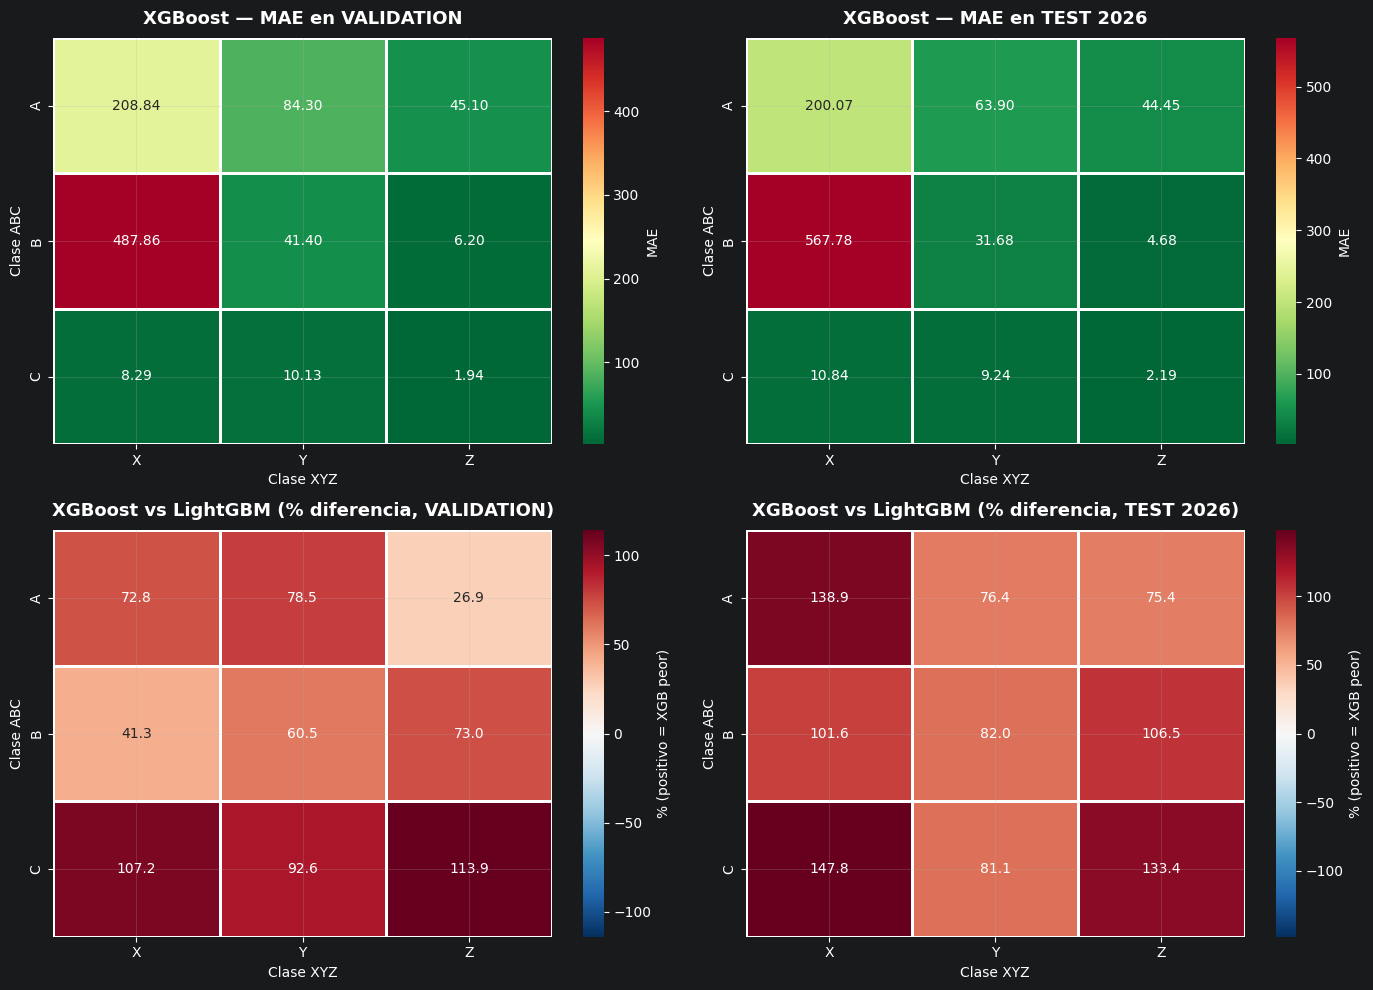


Lectura:
  Azul intenso = XGBoost mejor que LightGBM en ese segmento.
  Rojo intenso = LightGBM mejor que XGBoost.
  Cerca de cero = los dos modelos son equivalentes.


In [13]:
# Heatmaps comparativos: 4 paneles (XGB validation, XGB test, diff vs LGBM en cada uno)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(mae_xgb_valid, annot=True, fmt=".2f", cmap="RdYlGn_r",
            ax=axes[0, 0], cbar_kws={"label": "MAE"}, linewidths=1)
axes[0, 0].set_title("XGBoost — MAE en VALIDATION", pad=10)
axes[0, 0].set_xlabel("Clase XYZ")
axes[0, 0].set_ylabel("Clase ABC")

sns.heatmap(mae_xgb_test, annot=True, fmt=".2f", cmap="RdYlGn_r",
            ax=axes[0, 1], cbar_kws={"label": "MAE"}, linewidths=1)
axes[0, 1].set_title("XGBoost — MAE en TEST 2026", pad=10)
axes[0, 1].set_xlabel("Clase XYZ")
axes[0, 1].set_ylabel("Clase ABC")

# Diferencia % vs LightGBM (negativo = XGBoost mejor, positivo = LightGBM mejor)
diff_valid = ((mae_xgb_valid - mae_lgbm_valid) / mae_lgbm_valid * 100).round(2)
diff_test = ((mae_xgb_test - mae_lgbm_test) / mae_lgbm_test * 100).round(2)

# Usar cmap divergente con centro en 0
vmax_diff = max(abs(diff_valid.values.min()), abs(diff_valid.values.max()))
sns.heatmap(diff_valid, annot=True, fmt=".1f", cmap="RdBu_r",
            ax=axes[1, 0], cbar_kws={"label": "% (positivo = XGB peor)"},
            linewidths=1, center=0, vmin=-vmax_diff, vmax=vmax_diff)
axes[1, 0].set_title("XGBoost vs LightGBM (% diferencia, VALIDATION)", pad=10)
axes[1, 0].set_xlabel("Clase XYZ")
axes[1, 0].set_ylabel("Clase ABC")

vmax_diff_test = max(abs(diff_test.values.min()), abs(diff_test.values.max()))
sns.heatmap(diff_test, annot=True, fmt=".1f", cmap="RdBu_r",
            ax=axes[1, 1], cbar_kws={"label": "% (positivo = XGB peor)"},
            linewidths=1, center=0, vmin=-vmax_diff_test, vmax=vmax_diff_test)
axes[1, 1].set_title("XGBoost vs LightGBM (% diferencia, TEST 2026)", pad=10)
axes[1, 1].set_xlabel("Clase XYZ")
axes[1, 1].set_ylabel("Clase ABC")

plt.tight_layout()
guardar(fig, "01_comparacion_xgb_vs_lgbm")
plt.show()

print("\nLectura:")
print("  Azul intenso = XGBoost mejor que LightGBM en ese segmento.")
print("  Rojo intenso = LightGBM mejor que XGBoost.")
print("  Cerca de cero = los dos modelos son equivalentes.")

## 11. Feature importance — Comparación con LightGBM

In [14]:
# Feature importance de XGBoost (por gain)
fi_dict = modelo.get_score(importance_type="gain")
fi_xgb = pd.DataFrame({
    "feature": list(fi_dict.keys()),
    "importance_gain": list(fi_dict.values()),
}).sort_values("importance_gain", ascending=False).reset_index(drop=True)

print("Top 15 features por GAIN (XGBoost):")
print(fi_xgb.head(15))

Top 15 features por GAIN (XGBoost):
                 feature    importance_gain
0         rolling_mean_4 4,766,811,648.0000
1        rolling_mean_13   440,185,920.0000
2                 diff_1   263,416,880.0000
3   centro_operacion_cod   120,743,632.0000
4                  lag_1    99,202,328.0000
5             sku_median    79,583,592.0000
6             cos_semana    51,129,208.0000
7           num_festivos    43,888,312.0000
8                sin_mes    39,287,948.0000
9              trimestre    38,517,380.0000
10              sku_mean    38,219,080.0000
11                lag_13    36,952,804.0000
12              dia_anio    36,149,128.0000
13                lag_52    33,344,284.0000
14            sin_semana    32,220,924.0000


  Guardado: reports/figures/xgboost/02_feature_importance_xgb.png


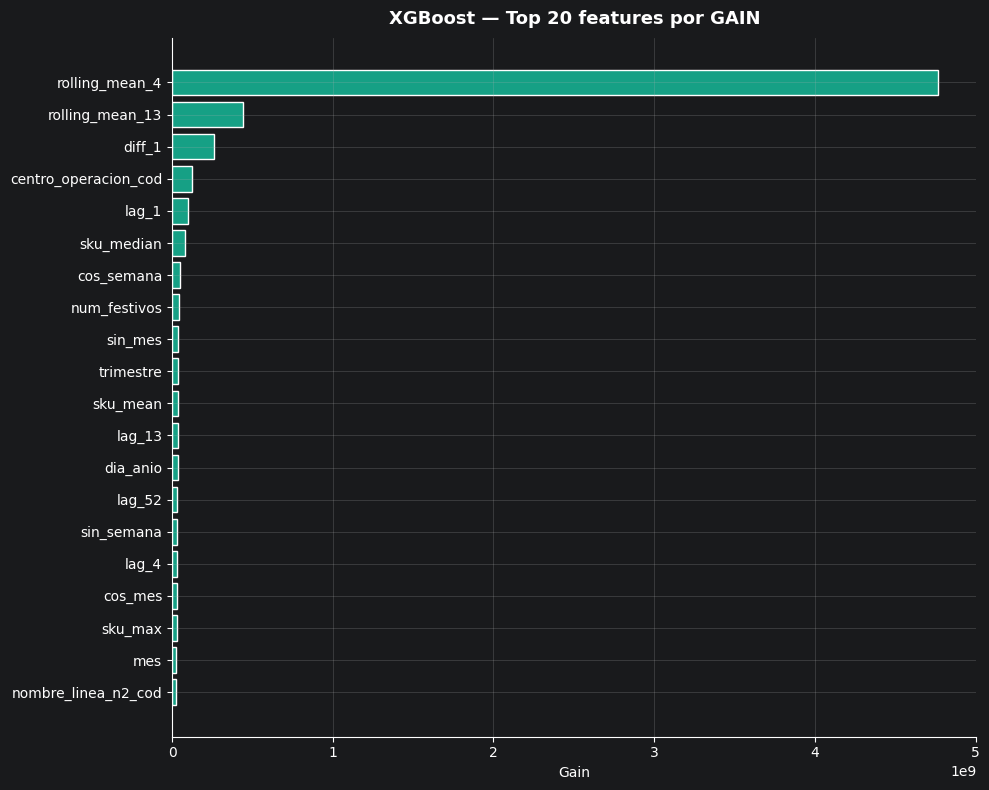

In [15]:
# Visualizar top 20
fig, ax = plt.subplots(figsize=(10, 8))
top_fi = fi_xgb.head(20)
ax.barh(top_fi["feature"][::-1], top_fi["importance_gain"][::-1],
        color=COLOR_XGBOOST, edgecolor="white")
ax.set_title("XGBoost — Top 20 features por GAIN", pad=10)
ax.set_xlabel("Gain")
plt.tight_layout()
guardar(fig, "02_feature_importance_xgb")
plt.show()

## 12. Visualizaciones — Real vs Baseline vs LightGBM vs XGBoost

  Guardado: reports/figures/xgboost/03_comparacion_triple_top_skus.png


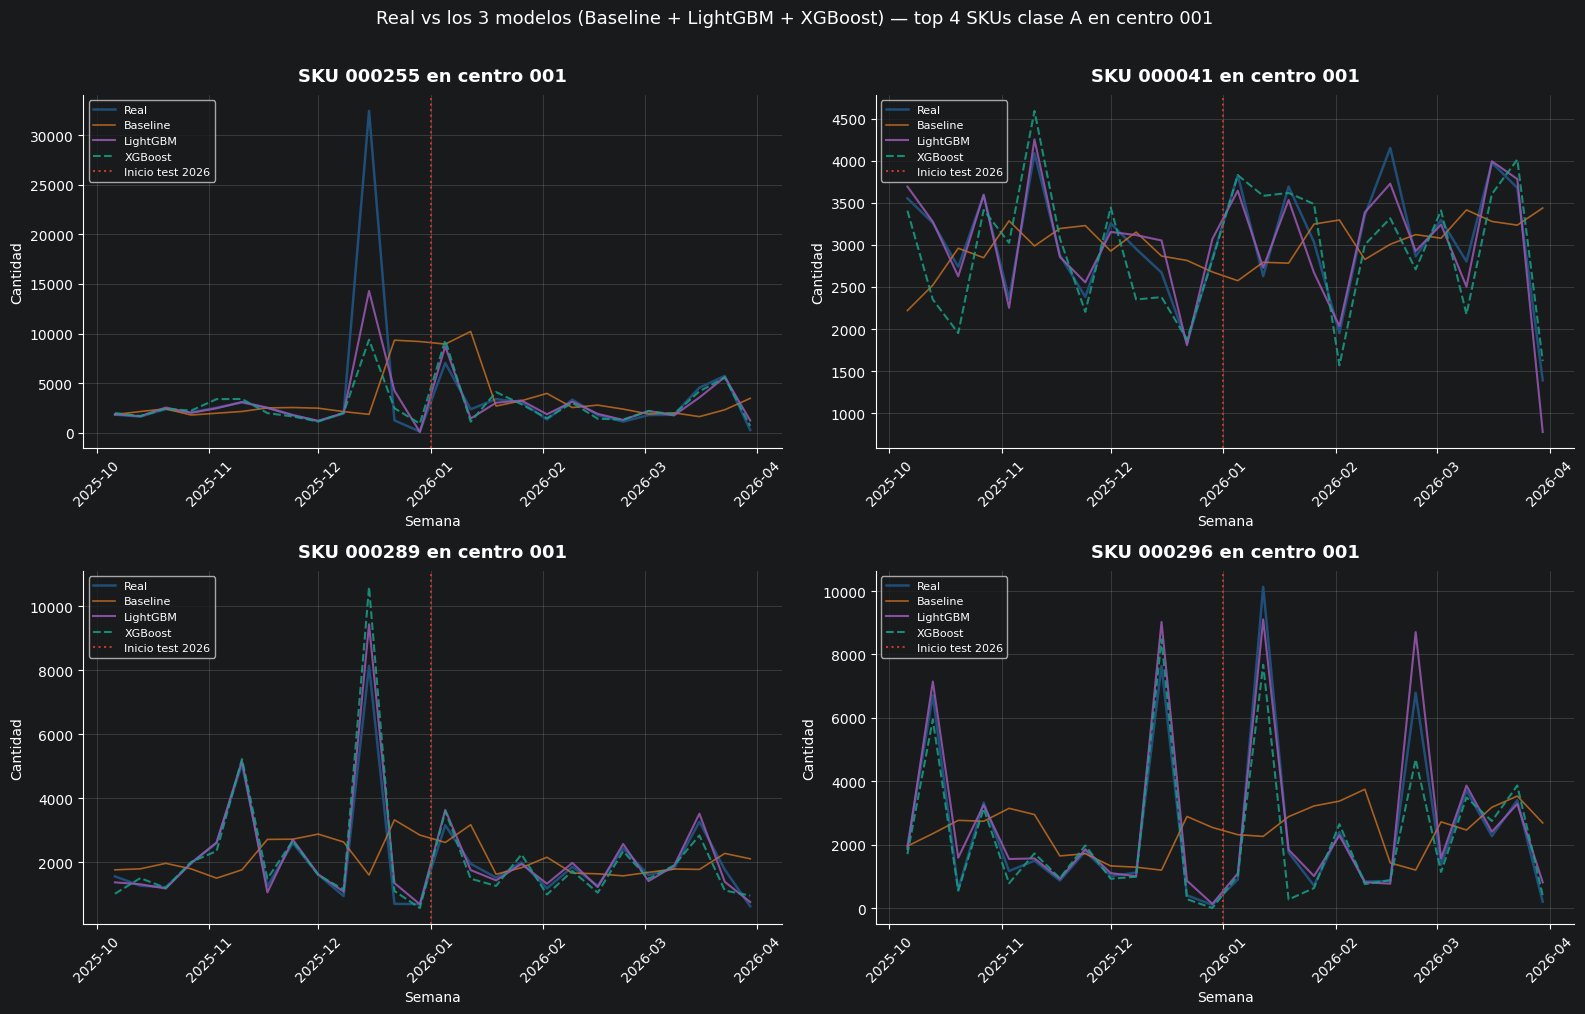

In [16]:
# Top 4 SKUs clase A en centro 001 (mismos que notebooks 05 y 06)
top_skus = (
    valid_full[(valid_full["clase_abc"] == "A") & (valid_full["centro_operacion"] == "001")]
    .groupby("item")["cantidad_total"].sum()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

combined = pd.concat([
    valid_full[["item", "centro_operacion", "fecha_inicio_semana", "cantidad_total",
                "pred_baseline", "pred_lightgbm", "y_pred_xgb"]],
    test_full[["item", "centro_operacion", "fecha_inicio_semana", "cantidad_total",
               "pred_baseline", "pred_lightgbm", "y_pred_xgb"]],
]).sort_values(["item", "centro_operacion", "fecha_inicio_semana"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, sku in enumerate(top_skus):
    ax = axes[i]
    sub = combined[(combined["item"] == sku) & (combined["centro_operacion"] == "001")]

    ax.plot(sub["fecha_inicio_semana"], sub["cantidad_total"],
            label="Real", color=COLOR_PRIMARIO, linewidth=1.8)
    ax.plot(sub["fecha_inicio_semana"], sub["pred_baseline"],
            label="Baseline", color=COLOR_SECUNDARIO, linewidth=1.2, alpha=0.7)
    ax.plot(sub["fecha_inicio_semana"], sub["pred_lightgbm"],
            label="LightGBM", color=COLOR_LIGHTGBM, linewidth=1.5, alpha=0.85)
    ax.plot(sub["fecha_inicio_semana"], sub["y_pred_xgb"],
            label="XGBoost", color=COLOR_XGBOOST, linewidth=1.5, alpha=0.85,
            linestyle="--")

    ax.axvline(pd.Timestamp("2026-01-01"), color=COLOR_ROJO, linestyle=":",
                linewidth=1.5, label="Inicio test 2026")

    ax.set_title(f"SKU {sku} en centro 001", pad=10)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Cantidad")
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Real vs los 3 modelos (Baseline + LightGBM + XGBoost) — top 4 SKUs clase A en centro 001",
             y=1.01, fontsize=13)
plt.tight_layout()
guardar(fig, "03_comparacion_triple_top_skus")
plt.show()

## 13. Análisis: ¿XGBoost vs LightGBM dónde gana cada uno?

In [17]:
# Por observacion: cual de los dos modelos tiene menor error?
valid_full["err_lgbm"] = np.abs(valid_full["cantidad_total"] - valid_full["pred_lightgbm"])
valid_full["err_xgb"] = np.abs(valid_full["cantidad_total"] - valid_full["y_pred_xgb"])
valid_full["xgb_mejor"] = valid_full["err_xgb"] < valid_full["err_lgbm"]
valid_full["lgbm_mejor"] = valid_full["err_lgbm"] < valid_full["err_xgb"]
valid_full["empate"] = valid_full["err_xgb"] == valid_full["err_lgbm"]

pct_xgb = valid_full["xgb_mejor"].mean() * 100
pct_lgbm = valid_full["lgbm_mejor"].mean() * 100
pct_empate = valid_full["empate"].mean() * 100

print(f"En validation, comparando XGBoost vs LightGBM observacion por observacion:")
print(f"  XGBoost gana: {pct_xgb:.2f}%")
print(f"  LightGBM gana: {pct_lgbm:.2f}%")
print(f"  Empate exacto: {pct_empate:.2f}%")
print()

# Por segmento
print("Detalle por clase ABC:")
analisis_seg = valid_full.groupby("clase_abc").agg(
    n_obs=("item", "count"),
    pct_xgb_gana=("xgb_mejor", lambda x: x.mean() * 100),
    pct_lgbm_gana=("lgbm_mejor", lambda x: x.mean() * 100),
    mae_xgb=("err_xgb", "mean"),
    mae_lgbm=("err_lgbm", "mean"),
)
print(analisis_seg.round(2))

En validation, comparando XGBoost vs LightGBM observacion por observacion:
  XGBoost gana: 9.33%
  LightGBM gana: 90.65%
  Empate exacto: 0.02%

Detalle por clase ABC:
           n_obs  pct_xgb_gana  pct_lgbm_gana  mae_xgb  mae_lgbm
clase_abc                                                       
A           3328       16.7400        83.1100  73.6000   45.7400
B          12557       13.6000        86.3700  41.5800   27.7900
C          48728        7.7300        92.2600   2.9500    1.4400


## 14. Guardado de modelo, predicciones y métricas

In [18]:
# Guardar modelo
ruta_modelo = ROOT / "data" / "processed" / "xgboost_model.json"
modelo.save_model(str(ruta_modelo))
print(f"Modelo guardado: {ruta_modelo.relative_to(ROOT)} ({ruta_modelo.stat().st_size / 1024:.1f} KB)")

Modelo guardado: data/processed/xgboost_model.json (718.7 KB)


In [19]:
# Guardar predicciones
pronosticos_xgb = pd.concat([
    valid_full[["item", "centro_operacion", "fecha_inicio_semana",
                "cantidad_total", "y_pred_xgb"]]
    .rename(columns={"cantidad_total": "cantidad_real", "y_pred_xgb": "cantidad_predicha"})
    .assign(split="valid", modelo="xgboost"),
    test_full[["item", "centro_operacion", "fecha_inicio_semana",
               "cantidad_total", "y_pred_xgb"]]
    .rename(columns={"cantidad_total": "cantidad_real", "y_pred_xgb": "cantidad_predicha"})
    .assign(split="test_2026", modelo="xgboost"),
])

with engine.begin() as conn:
    conn.execute(text("DELETE FROM pronosticos WHERE modelo = 'xgboost'"))

print(f"Guardando {len(pronosticos_xgb):,} predicciones de XGBoost...")
pronosticos_xgb.to_sql("pronosticos", engine, if_exists="append", index=False, chunksize=1000)

with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM pronosticos WHERE modelo='xgboost'")).scalar()
print(f"Predicciones XGBoost guardadas: {n:,} filas")

Guardando 131,185 predicciones de XGBoost...
Predicciones XGBoost guardadas: 131,185 filas


In [20]:
# Guardar metricas
metricas_resumen = pd.DataFrame([
    {"modelo": "xgboost", "split": "valid", "segmento": "global",
     "mae": metricas_valid["mae"], "rmse": metricas_valid["rmse"],
     "mape": metricas_valid["mape"], "smape": metricas_valid["smape"],
     "n_obs": metricas_valid["n_obs"]},
    {"modelo": "xgboost", "split": "test_2026", "segmento": "global",
     "mae": metricas_test["mae"], "rmse": metricas_test["rmse"],
     "mape": metricas_test["mape"], "smape": metricas_test["smape"],
     "n_obs": metricas_test["n_obs"]},
])

# Por clase ABC
for clase in ["A", "B", "C"]:
    sub_v = valid_full[valid_full["clase_abc"] == clase]
    sub_t = test_full[test_full["clase_abc"] == clase]
    if len(sub_v) > 0:
        mv = calcular_metricas(sub_v["cantidad_total"], sub_v["y_pred_xgb"])
        metricas_resumen = pd.concat([metricas_resumen, pd.DataFrame([{
            "modelo": "xgboost", "split": "valid", "segmento": f"abc_{clase}",
            "mae": mv["mae"], "rmse": mv["rmse"], "mape": mv["mape"], "smape": mv["smape"],
            "n_obs": mv["n_obs"],
        }])])
    if len(sub_t) > 0:
        mt = calcular_metricas(sub_t["cantidad_total"], sub_t["y_pred_xgb"])
        metricas_resumen = pd.concat([metricas_resumen, pd.DataFrame([{
            "modelo": "xgboost", "split": "test_2026", "segmento": f"abc_{clase}",
            "mae": mt["mae"], "rmse": mt["rmse"], "mape": mt["mape"], "smape": mt["smape"],
            "n_obs": mt["n_obs"],
        }])])

metricas_resumen = metricas_resumen.reset_index(drop=True)

with engine.begin() as conn:
    conn.execute(text("DELETE FROM metricas_modelos WHERE modelo = 'xgboost'"))

metricas_resumen.to_sql("metricas_modelos", engine, if_exists="append", index=False)
print(f"Metricas guardadas: {len(metricas_resumen)} filas en tabla metricas_modelos.")
metricas_resumen

Metricas guardadas: 8 filas en tabla metricas_modelos.


,modelo,split,segmento,mae,rmse,mape,smape,n_obs
0,xgboost,valid,global,14.0998,314.3289,48.4065,147.4862,64613
1,xgboost,test_2026,global,13.2478,258.4230,55.7100,146.9954,66572
2,xgboost,valid,abc_A,73.5982,568.8647,62.8808,97.0018,3328
3,xgboost,test_2026,abc_A,62.0799,301.8249,70.7748,95.6682,3328
4,xgboost,valid,abc_B,41.5815,644.4121,59.1423,125.3759,12557
5,xgboost,test_2026,abc_B,41.4012,570.7071,59.3160,125.9948,12571
6,xgboost,valid,abc_C,2.9543,43.5613,41.2827,156.6211,48728
7,xgboost,test_2026,abc_C,3.0564,30.8442,51.9920,155.5610,50673


## 15. Resumen final

In [21]:
print("=" * 80)
print("XGBOOST — RESUMEN FINAL Y COMPARACION CON LIGHTGBM")
print("=" * 80)
print(f"\nMejor iteracion: {modelo.best_iteration}")
print()
print(f"{'Metrica':<10} {'Baseline':>10} {'LightGBM':>10} {'XGBoost':>10} {'XGB-LGBM':>12}")
print("-" * 80)

for split_name, m_test in [("VALIDATION", metricas_valid), ("TEST 2026", metricas_test)]:
    print(f"\n{split_name}:")
    split_key = "valid" if split_name == "VALIDATION" else "test_2026"
    for met in ["mae", "rmse", "mape", "smape"]:
        base = get_metric(metricas_db, "baseline_ma4", split_key, met)
        lgbm = get_metric(metricas_db, "lightgbm", split_key, met)
        xgb_val = m_test[met]
        diff = xgb_val - lgbm
        sufijo = "%" if met in ["mape", "smape"] else ""
        diff_str = f"{diff:+.2f}{sufijo}"
        print(f"  {met.upper():<8} {base:>9.2f}{sufijo} {lgbm:>9.2f}{sufijo} {xgb_val:>9.2f}{sufijo} {diff_str:>12}")

print(f"\nObservaciones donde XGBoost gana a LightGBM: {pct_xgb:.2f}%")
print(f"Observaciones donde LightGBM gana a XGBoost:  {pct_lgbm:.2f}%")
print(f"Empates exactos:                              {pct_empate:.2f}%")
print()
print(f"Archivos generados:")
print(f"  - Modelo: data/processed/xgboost_model.json")
print(f"  - Predicciones: tabla pronosticos (modelo='xgboost')")
print(f"  - Metricas: tabla metricas_modelos (modelo='xgboost')")
print(f"  - Figuras: reports/figures/xgboost/")
print(f"\nSiguiente paso: notebook 08 (Prophet) para top 50 SKUs clase A.")
print("=" * 80)

XGBOOST — RESUMEN FINAL Y COMPARACION CON LIGHTGBM

Mejor iteracion: 172

Metrica      Baseline   LightGBM    XGBoost     XGB-LGBM
--------------------------------------------------------------------------------

VALIDATION:
  MAE          37.09      8.85     14.10        +5.25
  RMSE        494.29    237.68    314.33       +76.65
  MAPE        180.43%     28.62%     48.41%      +19.78%
  SMAPE       146.32%    143.59%    147.49%       +3.90%

TEST 2026:
  MAE          32.50      6.77     13.25        +6.48
  RMSE        389.01    144.97    258.42      +113.45
  MAPE        170.62%     28.76%     55.71%      +26.95%
  SMAPE       147.72%    142.46%    147.00%       +4.54%

Observaciones donde XGBoost gana a LightGBM: 9.33%
Observaciones donde LightGBM gana a XGBoost:  90.65%
Empates exactos:                              0.02%

Archivos generados:
  - Modelo: data/processed/xgboost_model.json
  - Predicciones: tabla pronosticos (modelo='xgboost')
  - Metricas: tabla metricas_modelos (mo

### Lectura para el informe (Capítulo 5)

El propósito de este notebook es **validar la robustez del enfoque metodológico** mediante un segundo algoritmo del mismo nivel (XGBoost).

- Si XGBoost y LightGBM dan resultados similares (~5% de diferencia): se confirma que el problema está bien planteado y las features son robustas.
- Si XGBoost es claramente superior o inferior: indica sensibilidad al algoritmo y requeriría más investigación.

En cualquiera de los dos casos, los hallazgos refuerzan el aporte del proyecto.